Лычаный НА N33471

Задача 2 "Экономические города"

Импортируем библиотеки.

In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline

from sklearn.cluster import KMeans

Маунтим Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Открываем датасет из гугл диска

In [3]:
df = pd.read_csv('/content/drive/MyDrive/itmo/3/теория алгоритмов/lab_2/Econom_Cities_data.csv', sep=";", index_col='City', decimal=',')
df.head()

,Work,Price,Salary
City,,,
Amsterdam,1714,65.6,49.0
Athens,1792,53.8,30.4
Bogota,2152,37.9,11.5
Bombay,2052,30.3,5.3
Brussels,1708,73.8,50.5


Размаунтим Google Drive



In [4]:
drive.flush_and_unmount()

Удаление выбросов по итогам прошлой работы

In [5]:
df.drop(df.index[[6,17]],inplace = True)

Стандартизируем данные

In [6]:
from sklearn import preprocessing

In [7]:
stand_1 = preprocessing.StandardScaler()
stand_1.fit(df)
X = stand_1.transform(df)
X = pd.DataFrame(X, index=df.index, columns=df.columns)

Применим модель для разного числа кластеров чтобы построить график каменистой осыпи.

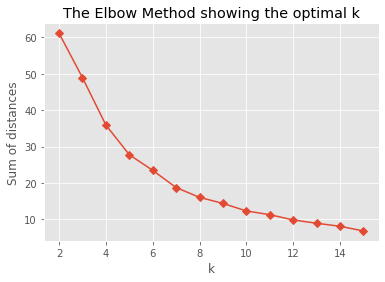

In [8]:
K = range(2, 16)
models = [KMeans(n_clusters=k,random_state=64).fit(X) for k in K]
dist = [model.inertia_ for model in models]

# Plot the elbow
plt.plot(K, dist, marker='D')
plt.xlabel('k')
plt.ylabel('Sum of distances')
plt.title('The Elbow Method showing the optimal k')
plt.show()

На графике очевидно, что после 8 сумма растояний уменьшается. Следовательно,  кол-во кластеров 8.

In [9]:
model = KMeans(n_clusters=8, random_state=64, max_iter=1000)
model.fit(X)
df['cluster'] = model.labels_
df.groupby('cluster').mean()

,Work,Price,Salary
cluster,,,
0,1988.000000,56.385714,14.571429
1,1696.400000,105.100000,56.480000
2,1990.833333,77.233333,55.316667
3,2375.000000,63.800000,27.800000
4,1798.857143,50.942857,19.214286
5,1876.000000,103.633333,86.100000
6,1735.083333,75.733333,53.141667
7,2143.400000,40.180000,8.900000


In [10]:
df['cluster'].sort_values()

City
Mexico_City       0
Nairobi           0
Tel_Aviv          0
Buenos_Aires      0
Caracas           0
Singpore          0
Johannesburg      0
Madrid            1
Oslo              1
Copenhagen        1
Stockholm         1
Helsinki          1
New_York          2
Houston           2
Taipei            2
Chicago           2
Toronto           2
Los_Angeles       2
Hong_Kong         3
San_Paulo         4
Rio_de_Janeiro    4
Nicosia           4
Lisbon            4
Lagos             4
Athens            4
Seoul             4
Geneva            5
Tokyo             5
Zurich            5
Sydney            6
Paris             6
Amsterdam         6
Milan             6
Vienna            6
London            6
Frankfurt         6
Dusseldorf        6
Dublin            6
Brussels          6
Montreal          6
Luxembourg        6
Panama            7
Manila            7
Kuala_Lumpur      7
Bombay            7
Bogota            7
Name: cluster, dtype: int32

Мы получили 8 разумно сгруппированных кластеров:


1.   Много работают, средняя стоимость проживания, очень низкая зарплата - **города Южной америки и Африки**
2.   Среднее кол-во часов работы, самая высокая стоимость проживания, средняя зарплата - **города Скандинавии и Япония**
3.Среднее кол-во часов работы, средняя стоимость проживания, средняя зарплата - **промышленно-развитые города или со средним уровнем жизни**
4.Самое большое кол-во часов работы, самая низкая стоимость проживания, самая низкая зарплата - **города с высокой плотностью населения и низким уровнем жизни**
5.Среднее кол-во часов работы, высокая стоимость проживания, средняя зарплата - **главные города Европы (столицы и популярные города)**
6.Большое кол-во часов работы, средняя стоимость проживания, низкая зарплата - **города с высокой плотностью населения и среднем уровнем жизни**
7.Большое кол-во часов работы, высокая стоимость проживания, средняя зарплата - **Столица Китайской народной республики, столица США и вторая "негласная" столица США**
8.Среднее кол-во часов работы, высокая стоимость проживания, самая высокая зарплата - **Швейцария**

Данные кластеры полностью совпадают с экономическим положением гордов в 1991 году.

Вывод: k-means разделил на более оптимальные кластеры, объединив по очень важным показателям данные, которые в полной мере раскрывают анализ экономического положения городов и стран